Synthesize Criteo data using sequential CART models. (Note that this file uses the updated synthesis and optimization functions from the `helper_functions.py` file.).

In [1]:
import matplotlib.pyplot as plt
import sys

# Add the parent directory to path
sys.path.append('..')

# Then import
from helper_functions import *

rng = np.random.RandomState(42)

Import Criteo data (small version for testing)

In [2]:
train_data = pd.read_csv("../../Data/Criteo/cleaned_criteo_os.gz",
                         compression='gzip', 
                         sep='\,',
                         header=0,
                         engine='python')
data_set = "os"

View confidential data to synthesize.

In [3]:
train_data

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,25.943876,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
1,25.256743,10.059654,8.214383,4.679882,10.280525,4.115453,-6.699321,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.327794,4.679882,11.561050,4.115453,0.294443,4.833815,3.854508,29.642144,6.175174,-0.168679,1,0,0,0
3,26.279296,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
4,23.648783,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81543,13.680284,10.059654,8.325934,-0.600592,11.029584,1.128518,-13.045950,10.885556,3.758296,44.784329,5.844038,-0.267350,1,1,1,1
81544,14.251906,13.579750,8.303577,-2.272900,12.594889,-4.636110,-19.328059,5.621479,3.755250,42.018683,6.141586,-0.168679,1,1,1,1
81545,20.711370,10.059654,8.290111,4.679882,10.280525,4.115453,-6.359690,4.833815,3.813849,26.606156,5.300375,-0.168679,1,1,1,1
81546,23.767207,10.059654,8.283185,4.679882,10.280525,4.115453,-3.282109,4.833815,3.767224,46.714867,5.300375,-0.168679,1,1,1,0


How many control group observations do we have?

In [6]:
np.mean(train_data.treatment == 0) * train_data.shape[0]

np.float64(10213.0)

Set up dictionary of parameter bounds for the Bayesian optimization process. The current state of the code requires a set of bounds for each parameter being optimized.

In [7]:
# define some default bounds for leaf values. These will be appropriately filled in during the loop below

param_bounds = {
    'tree': {
        'f0': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f1': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f2': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f3': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f4': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f5': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f6': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f7': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f8': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [4063, 10000]  # [min, max] bounds
        },
        'f9': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f10': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f11': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        }
    }
}

In [8]:
min_bound = 5

synthesis_cols, synthesis_steps, synthesis_bounds = define_synthesis_steps(train_data = train_data, 
                                                                           current_param_bounds=param_bounds,
                                                                           lower_bound=min_bound)

In [9]:
synthesis_cols

['treatment',
 'exposure',
 'visit',
 'conversion',
 'f8',
 'f9',
 'f3',
 'f4',
 'f6',
 'f5',
 'f11',
 'f1',
 'f10',
 'f0',
 'f7',
 'f2']

In [10]:
synthesis_steps

[(['treatment', 'exposure', 'visit', 'conversion'], 'joint_categorical'),
 (['f8', 'f9', 'f3', 'f4', 'f6', 'f5', 'f11', 'f1', 'f10', 'f0', 'f7', 'f2'],
  'tree')]

In [11]:
synthesis_bounds

{'tree': {'f0': {'min_samples_leaf': [5, 40774]},
  'f1': {'min_samples_leaf': [5, 5]},
  'f2': {'min_samples_leaf': [5, 5]},
  'f3': {'min_samples_leaf': [5, 40774]},
  'f4': {'min_samples_leaf': [5, 40774]},
  'f5': {'min_samples_leaf': [5, 40774]},
  'f6': {'min_samples_leaf': [5, 40774]},
  'f7': {'min_samples_leaf': [5, 40774]},
  'f8': {'min_samples_leaf': [231, 40774]},
  'f9': {'min_samples_leaf': [5, 40774]},
  'f10': {'min_samples_leaf': [5, 5]},
  'f11': {'min_samples_leaf': [5, 40774]}}}

Define additional parameters of the optimization process:

- num_synthetic_datasets: Number of synthetic datasets to generate on each iteration of the optimizer (usually use 10 to reduce compute time)
- num_iter_optimization: Number of iterations to run the optimizer (default is 25, can run longer to try to find a better solution)
- num_init_optimization: Number of initializations to perform prior to optimized iterations (usually 3-5, this just starts the optimizer)
- random_states: run the optimizer all the way through for each random seed in this list

In [12]:
number_synthetic_datasets = 10
num_iter_optimization = 25
num_init_optimization = 5
random_states = [1006, 428]

Compute target parameters.

In [13]:
# reorder the columns in the training data to match the synthesis order
train_data = train_data[synthesis_cols]

In [14]:
train_data

,treatment,exposure,visit,conversion,f8,f9,f3,f4,f6,f5,f11,f1,f10,f0,f7,f2
0,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-2.411115,4.115453,-0.168679,10.059654,5.300375,25.943876,4.833815,8.214383
1,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-6.699321,4.115453,-0.168679,10.059654,5.300375,25.256743,4.833815,8.214383
2,1,0,0,0,3.854508,29.642144,4.679882,11.561050,0.294443,4.115453,-0.168679,10.059654,6.175174,12.616365,4.833815,8.327794
3,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-1.288207,4.115453,-0.168679,10.059654,5.300375,26.279296,4.833815,8.214383
4,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-1.288207,4.115453,-0.168679,10.059654,5.300375,23.648783,4.833815,8.214383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81543,1,1,1,1,3.758296,44.784329,-0.600592,11.029584,-13.045950,1.128518,-0.267350,10.059654,5.844038,13.680284,10.885556,8.325934
81544,1,1,1,1,3.755250,42.018683,-2.272900,12.594889,-19.328059,-4.636110,-0.168679,13.579750,6.141586,14.251906,5.621479,8.303577
81545,1,1,1,1,3.813849,26.606156,4.679882,10.280525,-6.359690,4.115453,-0.168679,10.059654,5.300375,20.711370,4.833815,8.290111
81546,1,0,1,1,3.767224,46.714867,4.679882,10.280525,-3.282109,4.115453,-0.168679,10.059654,5.300375,23.767207,4.833815,8.283185


In [15]:
target_variable = 'conversion'
exog_variables = list(train_data.drop(target_variable, axis=1).columns)

In [16]:
target_params = logit_params(X = train_data[exog_variables], y = train_data[target_variable])

In [17]:
target_params

intercept    -2.771640
treatment    -0.196436
exposure      1.292908
visit        12.093285
f8            1.124690
f9           -0.022516
f3           -0.083690
f4            0.709608
f6            0.008768
f5           -0.422241
f11          -5.454938
f1           -1.210755
f10           0.445747
f0            0.010779
f7           -0.081255
f2           -0.871043
dtype: float64

Use the `optimization_models` function to perform the optimized synthesis process. The function returns the objective value associated with each iteration, the best set of parameters for each random seed, and the final optimization object from the Bayesian optimization function.

In [18]:
# import warnings
# warnings.filterwarnings('ignore')

# we are silencing harmless overflow warnings from numpy related to the Yeo-johnson transformation
# these warnings are not related to the optimization process and can be safely ignored

optimization_results = [optimize_models_with_param_target(train_data=train_data,
                                                          number_synthetic_datasets=number_synthetic_datasets,
                                                          synthesis_steps=synthesis_steps,
                                                          param_bounds=synthesis_bounds,
                                                          random_state=r,
                                                          target_params=target_params,
                                                          target_variable=target_variable,
                                                          exog_variables=exog_variables,
                                                          n_iter=num_iter_optimization,
                                                          n_init=num_init_optimization) for r in random_states]

Optimizing 12 parameters: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']
|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |    x6     |    x7     |    x8     |    x9     |    x10    |    x11    |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | -32.61915 | 30301.559 | 5.0       | 5.0       | 35977.749 | 30202.548 | 29410.193 | 12046.036 | 21429.777 | 7275.9351 | 33107.765 | 5.0       | 10463.069 |
| 2         | -59.83795 | 9676.8112 | 5.0       | 5.0       | 8240.7677 | 40067.896 | 39988.322 | 29962.218 | 16691.955 | 25319.463 | 3234.9976 | 5.0       | 24687.409 |
| 3         | -12.75525 | 18370.905 | 5.0       | 5.0       | 11788.327 | 40578.676 | 33304.212 | 10809.998 | 14602.234 | 27382.066 | 37744.301 | 5.0       | 34094.961 |
| 4         | -10.66335 | 8311.8025 | 5.0       |

In [19]:
run_targets = [np.minimum.accumulate(-i['optimizer'].space.target) for i in optimization_results]

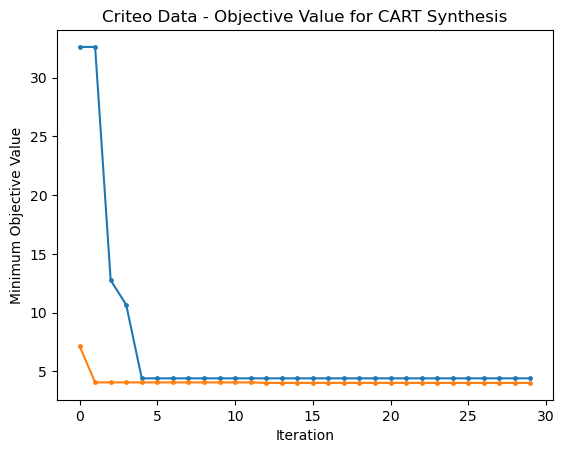

In [20]:
fig = plt.figure()
plt.plot(run_targets[0])
plt.scatter(np.arange(len(run_targets[0])), run_targets[0], s=6)
plt.plot(run_targets[1])
plt.scatter(np.arange(len(run_targets[1])), run_targets[1], s=6)
plt.title("Criteo Data - Objective Value for CART Synthesis")
plt.xlabel("Iteration")
plt.ylabel("Minimum Objective Value")
plt.show()

In [21]:
optimization_results

[{'best_params': {'gmm': {},
   'multinomial': {},
   'tree': {'f8': {'min_samples_leaf': np.float64(4904.243179445301)},
    'f9': {'min_samples_leaf': np.float64(5.0)},
    'f3': {'min_samples_leaf': np.float64(5.0)},
    'f4': {'min_samples_leaf': np.float64(28941.63458921366)},
    'f6': {'min_samples_leaf': np.float64(8135.01569111706)},
    'f5': {'min_samples_leaf': np.float64(15365.284921786082)},
    'f11': {'min_samples_leaf': np.float64(32855.95859722198)},
    'f1': {'min_samples_leaf': np.float64(10607.185225035118)},
    'f10': {'min_samples_leaf': np.float64(4352.643767412455)},
    'f0': {'min_samples_leaf': np.float64(37617.16775367243)},
    'f7': {'min_samples_leaf': np.float64(5.0)},
    'f2': {'min_samples_leaf': np.float64(22047.09081683788)}}},
  'best_score': np.float64(4.40417071434627),
  'optimizer': <bayes_opt.bayesian_optimization.BayesianOptimization at 0x29657b4b350>},
 {'best_params': {'gmm': {},
   'multinomial': {},
   'tree': {'f8': {'min_samples_leaf

In [22]:
best_params = optimization_results[np.argmin([x['best_score'] for x in optimization_results])]['best_params']

In [23]:
best_state = random_states[np.argmin([x['best_score'] for x in optimization_results])]

In [24]:
# warnings.filterwarnings('ignore')

# again, we are silencing harmless overflow warnings from numpy related to the Yeo-johnson transformation

sds, full_sXs = perform_synthesis_with_param_target(
    train_data=train_data,
    number_synthetic_datasets=20,
    synthesis_steps=synthesis_steps,
    target_params=target_params,
    target_variable=target_variable,
    exog_variables=exog_variables,
    param_values=best_params,
    random_state=best_state
)

In [25]:
np.mean(sds)

np.float64(5.2854094677208625)

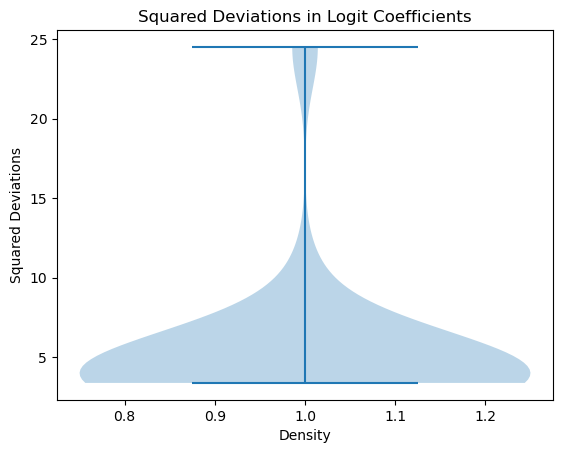

In [26]:
plt.violinplot(sds)
plt.xlabel("Density")
plt.ylabel("Squared Deviations")
plt.title("Squared Deviations in Logit Coefficients")
plt.show()

In [27]:
synthetic_data_path = "../../Data/Criteo/"

for i, sX in enumerate(full_sXs):
    if not os.path.exists(synthetic_data_path):
        os.makedirs(synthetic_data_path)
    sX.to_csv(synthetic_data_path + "cart_" + str(i) + "_" + data_set + ".csv", index=False)

End of file.